In [8]:
#1. import images into array
#2. convert to grayscale w/ t=0
#3. apply median
#4. apply gaussian

In [9]:
import cv2
import numpy as np
import glob
#uncomment when testing on colab v
#from google.colab.patches import cv2_imshow

In [26]:
path = "./Project-Images/*.jpg"
tumors_original = []
#img_names=["Te-aug-me_1.jpg","Te-aug-me_2.jpg","Te-aug-me_18.jpg","Te-gl_1.jpg","Te-gl_102.jpg","Te-gl_115.jpg","Te-no_1.jpg","Te-pi_12.jpg","Te-pi_101.jpg","Te-pi_105.jpg"]

for file in glob.glob(path):
    img= cv2.imread(file,0)
    if img is not None:
        tumors_original.append(img)

In [27]:
#reused median filter from lab 3:
def median_filter(image, filter_dim):
  image_h,image_w=image.shape
  #calculate the amt of padding needed (using floor division of filter dimension by 2)
  #e.g. 1 layer of 0 padding if filter is 3x3
  padding=filter_dim//2
  #create a blank array same size as original image to store result
  filtered_image=np.zeros((image_h,image_w),dtype=np.float64)
  #pad the original image with 0s depending on the values calculated earlier
  #this pads the top and bottom edges w/ # floor(rows/2) and the left and right edges w/ # floor(cols/2)
  padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
  #now apply the filter:
  for i in range(image_h):
        for j in range(image_w):
            #select region of interest starting at current position in original image that is size of filter
            region = padded_image[i:i + filter_dim, j:j + filter_dim]
            #flatten region to 1d vectorand sort it
            region=np.sort(region.flatten())
            #now we can calculate median of region and store it in the corresponding pixel of the median filtered image
            filtered_image[i, j] = np.median(region)
  #return the image as type uint8 with values clipped to 0,255 so that cv2 can display it
  return np.clip(filtered_image, 0, 255).astype(np.uint8)

In [28]:
#reuse gaussian filter function from lab 3
def gaussian_filter(image,filter_size,sigma):
  #get height and width of original image and the filter
  image_h,image_w=image.shape
  #calculate the amt of padding needed (depends on each filter dimension)
  padding=filter_size//2

  #create gaussian filter:
  # find the center of the filter/kernel
  center = filter_size // 2
  c=0
  if filter_size%2==1:
    c=1
  # creat a grid of coordinates using the calculated center value
  x, y = np.mgrid[-center:center+c, -center:center+c]

  # calculate gaussian value for each point in grid
  # using gaussian pdf: 1 / (2 * pi * sigma^2) * e^(-(x^2 + y^2) / (2 * sigma^2))
  filter = np.exp(-(x**2 + y**2) / (2.0 * sigma**2))

  # normalize the filter so all values sum to 1
  filter /= np.sum(filter)

  #create a blank array same size as original image to store result
  filtered_image=np.zeros((image_h,image_w),dtype=np.float64)
  #pad the original image with 0s depending on the values calculated earlier
  #this pads the top and bottom edges w/ # rows mod 2 and the left and right edges w/ # cols mod 2--1 if odd, and 0 if even
  padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
  #now apply the filter:
  for i in range(image_h):
        for j in range(image_w):
            #select region of interest shifted by i and j that is size of filter
            region = padded_image[i:i + filter_size, j:j + filter_size]
            #take dot product between region of interest and filter values
            convolution_sum = np.sum(region * filter)
            #store dot product as value in row i column j of the new, filtered image
            filtered_image[i, j] = convolution_sum
  #return the image as type uint8 with values clipped to 0,255 so that cv2 can display it
  return np.clip(filtered_image, 0, 255).astype(np.uint8)


In [29]:
tumors_processed=list(range(10))
for i in range(len(tumors_processed)):
    tumors_processed[i]=median_filter(tumors_original[i],3) #3x3 filter
    tumors_processed[i]=gaussian_filter(tumors_processed[i],3,5) #3x3 filter, sigma=5

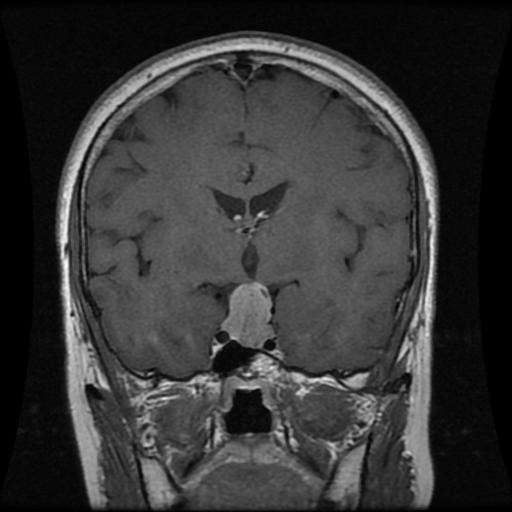

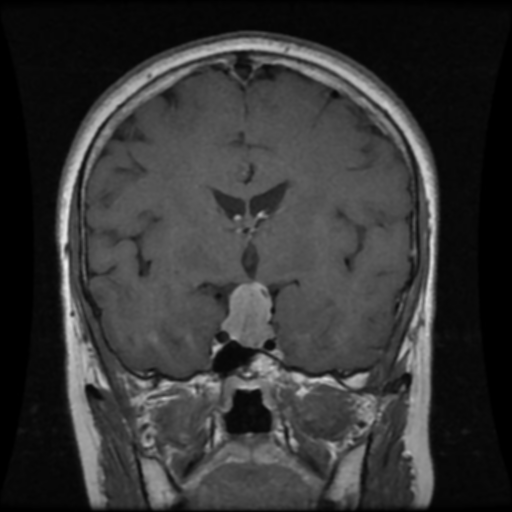

In [33]:
#cv2_imshow(tumors_original[2])
#cv2_imshow(tumors_processed[2])